# Camera Geometry Estimation

In [1]:
import pycolmap
from utils import generate_pattern, camera_geometry
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cv2
import open3d as o3d
from pathlib import Path
import sqlite3
from dataclasses import dataclass, field

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
@dataclass
class Camera:
    """Pinhole camera model.  R, t describe world→camera transform."""
    image_path: str
    K: np.ndarray           # 3×3 intrinsic matrix
    R: np.ndarray           # 3×3 rotation  (world→cam)
    t: np.ndarray           # (3,) translation (world→cam)
    is_virtual: bool = False
    fixed: bool = False     # virtual cameras are fixed during BA
 
    @property
    def center(self) -> np.ndarray:
        """Camera centre in world coordinates  C = -R^T t"""
        return -self.R.T @ self.t

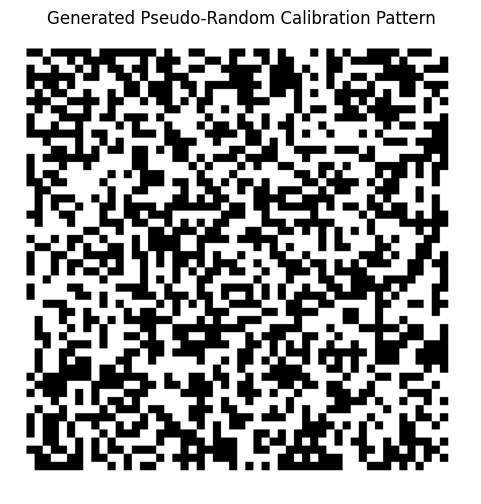

In [3]:
PATTERN_SIZE_MM = 130
DPI             = 300
GRID_CELLS      = 52
SEED            = 42
BORDER_MM       = 5
MM_PER_INCH     = 25.4

pattern_px  = int((PATTERN_SIZE_MM / MM_PER_INCH) * DPI)   # pattern region in pixels
border_px   = int((BORDER_MM       / MM_PER_INCH) * DPI)   # white border in pixels
canvas_px   = pattern_px + 2 * border_px                    # total canvas size
cell_px     = pattern_px // GRID_CELLS                      # one cell side in pixels
HALF_PLATE  = PATTERN_SIZE_MM / 2.0                         # 65 mm, used later

# ── Generate pattern ──────────────────────────────────────────────────────────
img_plate, canvas_size = generate_pattern.generate_pattern(PATTERN_SIZE_MM, DPI, GRID_CELLS, SEED, BORDER_MM)

# ── Visualise ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.imshow(img_plate, cmap='gray')
plt.title("Generated Pseudo-Random Calibration Pattern")
plt.axis('off')
plt.show()

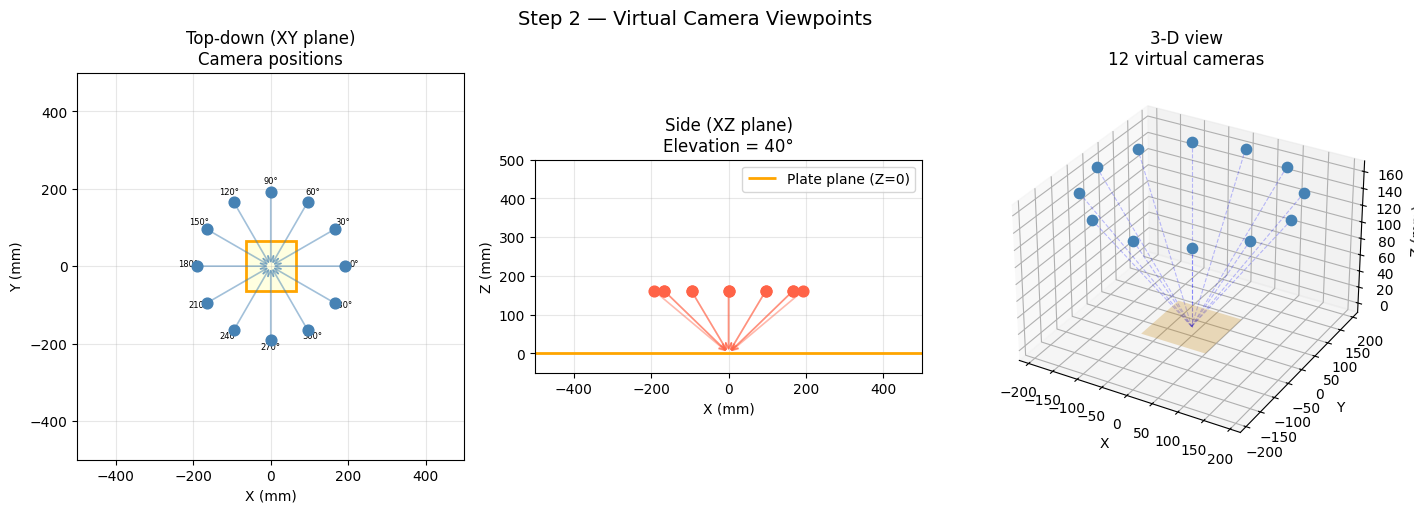

   Az     cam_x     cam_y     cam_z  mm
    0°     191.5       0.0     160.7
   30°     165.9      95.8     160.7
   60°      95.8     165.9     160.7
   90°       0.0     191.5     160.7
  120°     -95.8     165.9     160.7
  150°    -165.9      95.8     160.7
  180°    -191.5       0.0     160.7
  210°    -165.9     -95.8     160.7
  240°     -95.8    -165.9     160.7
  270°      -0.0    -191.5     160.7
  300°      95.8    -165.9     160.7
  330°     165.9     -95.8     160.7


In [15]:
# ── Scene parameters ──────────────────────────────────────────────────────────
# Measure your actual setup and adjust these three values before running.
CAMERA_DIST_MM = 250.0   # camera-to-plate-centre distance (mm); measure your setup
ELEVATION_DEG  = 40.0    # camera elevation above plate plane (°); adjust to match your photos
AZIMUTHS_DEG   = np.arange(0, 360, 30)   # 36 azimuths to match 36 real photos

# Compute all poses
camera_poses = [
    dict(zip(("az", "R", "t", "pos"), (az, *camera_geometry.camera_pose(az, ELEVATION_DEG, CAMERA_DIST_MM))))
    for az in AZIMUTHS_DEG
]

# ── Visualise ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))

# — Top-down (XY) view —
ax1 = fig.add_subplot(131)
plate_rect = mpatches.FancyBboxPatch(
    (-HALF_PLATE, -HALF_PLATE), PATTERN_SIZE_MM, PATTERN_SIZE_MM,
    boxstyle="square,pad=0", linewidth=2, edgecolor="orange", facecolor="lightyellow",
)
ax1.add_patch(plate_rect)
for cp in camera_poses:
    px, py = cp["pos"][:2]
    ax1.annotate("", xy=(0, 0), xytext=(px, py),
                 arrowprops=dict(arrowstyle="->", color="steelblue", alpha=0.5, lw=1.2))
    ax1.scatter(px, py, s=60, color="steelblue", zorder=4)
    ax1.text(px * 1.12, py * 1.12, f"{int(cp['az'])}°", fontsize=6, ha="center")
ax1.set_aspect("equal"); ax1.set_xlim(-500, 500); ax1.set_ylim(-500, 500)
ax1.set_xlabel("X (mm)"); ax1.set_ylabel("Y (mm)")
ax1.set_title("Top-down (XY plane)\nCamera positions"); ax1.grid(alpha=0.3)

# — Side (XZ) view —
ax2 = fig.add_subplot(132)
ax2.hlines(0, -500, 500, colors="orange", linewidths=2, label="Plate plane (Z=0)")
for cp in camera_poses:
    px, pz = cp["pos"][0], cp["pos"][2]
    ax2.annotate("", xy=(0, 0), xytext=(px, pz),
                 arrowprops=dict(arrowstyle="->", color="tomato", alpha=0.45, lw=1.2))
    ax2.scatter(px, pz, s=60, color="tomato", zorder=4)
ax2.set_aspect("equal"); ax2.set_xlim(-500, 500); ax2.set_ylim(-50, 500)
ax2.set_xlabel("X (mm)"); ax2.set_ylabel("Z (mm)")
ax2.set_title(f"Side (XZ plane)\nElevation = {int(ELEVATION_DEG)}°"); ax2.legend(); ax2.grid(alpha=0.3)

# — 3-D view —
ax3 = fig.add_subplot(133, projection="3d")
xx, yy = np.meshgrid([-HALF_PLATE, HALF_PLATE], [-HALF_PLATE, HALF_PLATE])
ax3.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.25, color="orange")
for cp in camera_poses:
    p = cp["pos"]
    ax3.scatter(*p, s=55, color="steelblue")
    ax3.plot([p[0], 0], [p[1], 0], [p[2], 0], "b--", alpha=0.25, lw=0.8)
ax3.set_xlabel("X"); ax3.set_ylabel("Y"); ax3.set_zlabel("Z (mm)")
ax3.set_title(f"3-D view\n{len(AZIMUTHS_DEG)} virtual cameras"); ax3.set_box_aspect([1, 1, 0.7])

plt.suptitle("Step 2 — Virtual Camera Viewpoints", fontsize=14)
plt.tight_layout()
plt.show()

print(f"{'Az':>5}  {'cam_x':>8}  {'cam_y':>8}  {'cam_z':>8}  mm")
for cp in camera_poses:
    p = cp["pos"]
    print(f"{int(cp['az']):>5}°  {p[0]:>8.1f}  {p[1]:>8.1f}  {p[2]:>8.1f}")

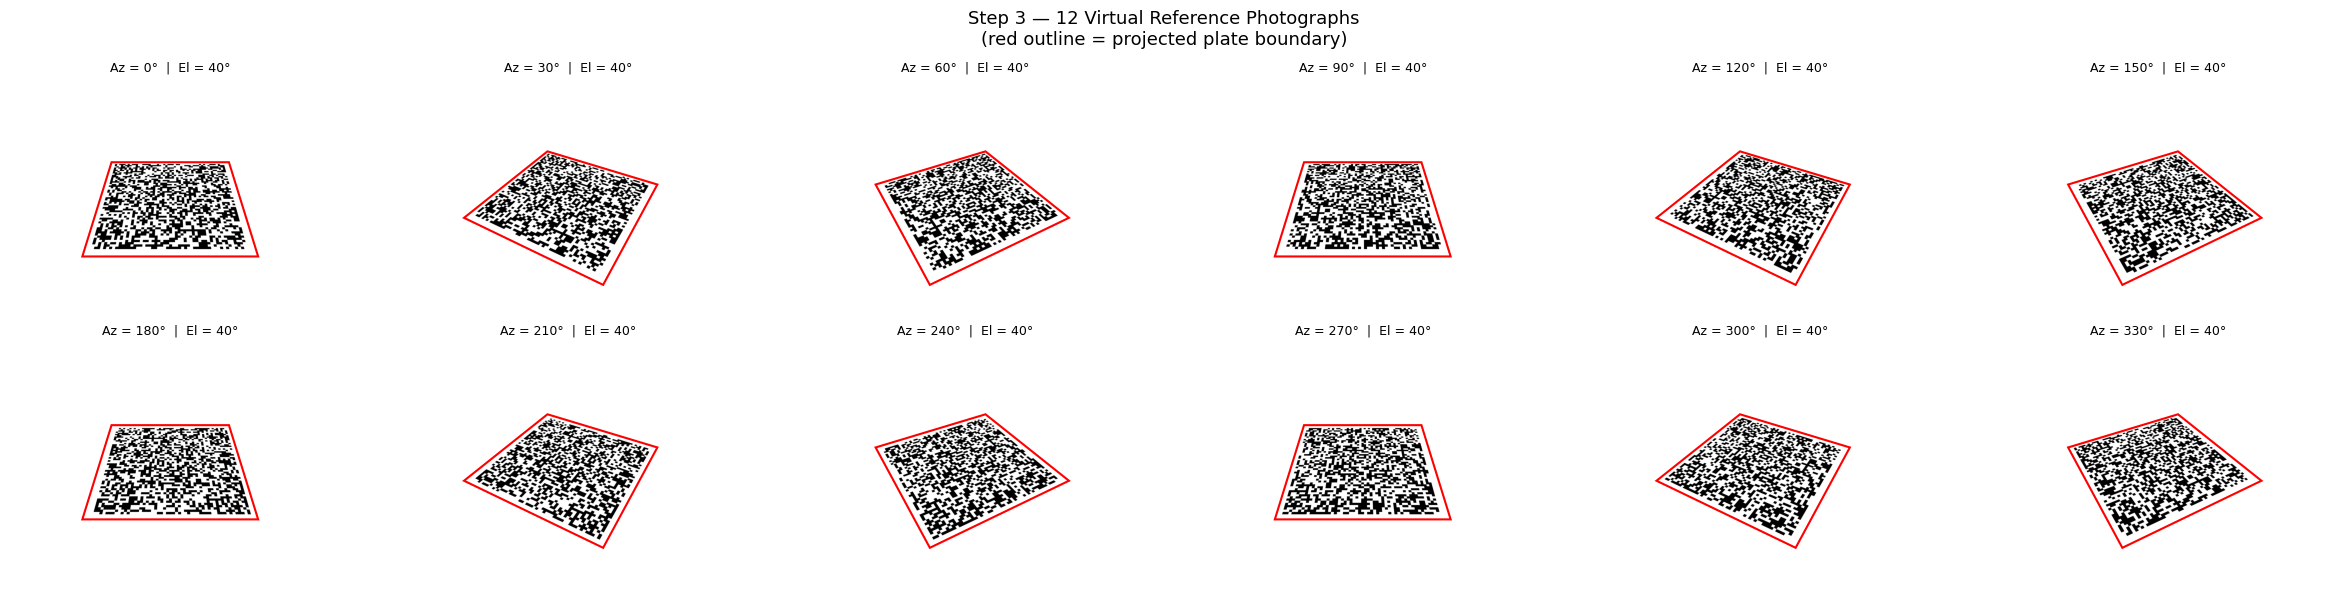

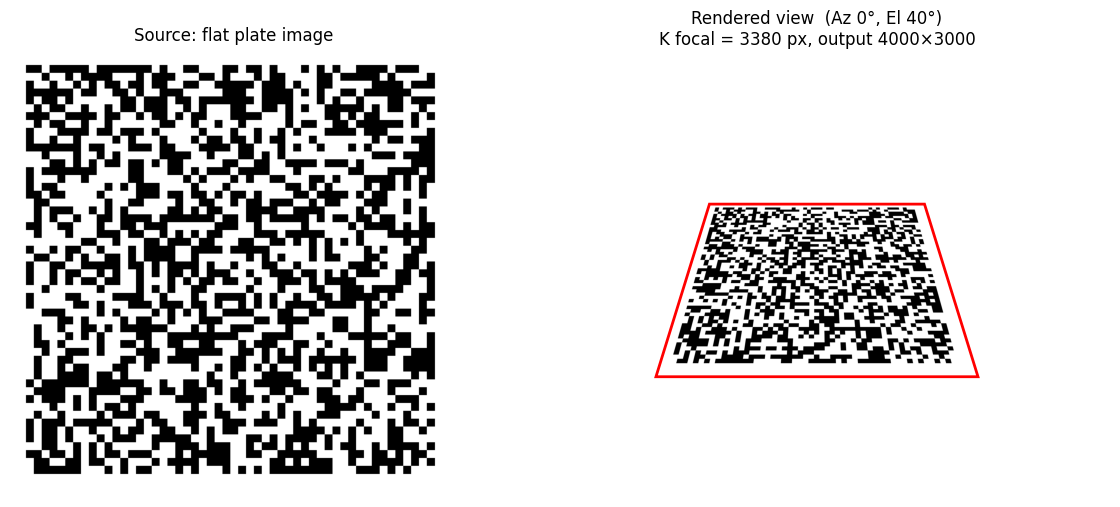

Intrinsic matrix K:
[[3.3797892e+03 0.0000000e+00 2.0000000e+03]
 [0.0000000e+00 3.3797892e+03 1.5000000e+03]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]

Rendered 12 virtual images  (4000×3000 px each)


In [16]:
# ── Synthetic camera intrinsics ───────────────────────────────────────────────
OUT_W, OUT_H = 4000, 3000   # kept here as fallback if calibration cell was skipped
FOCAL_PX = 3379.78920 # Came from prior camera calibration

CX, CY = OUT_W / 2.0, OUT_H / 2.0

K = np.array([
    [FOCAL_PX,       0,  CX],
    [      0,  FOCAL_PX,  CY],
    [      0,        0,    1],
], dtype=np.float64)

# Plate corners in 3-D world (mm) and corresponding source pixel corners
plate_corners_3d = np.array([
    [-HALF_PLATE, -HALF_PLATE, 0],
    [ HALF_PLATE, -HALF_PLATE, 0],
    [ HALF_PLATE,  HALF_PLATE, 0],
    [-HALF_PLATE,  HALF_PLATE, 0],
], dtype=np.float64)

img_plate = np.array(img_plate, dtype=np.uint8)
H_src, W_src = img_plate.shape[:2]
src_corners = np.array(
    [[0, 0], [W_src, 0], [W_src, H_src], [0, H_src]], dtype=np.float32
)
dist_zeros = np.zeros(5)


def render_view(plate_gray, R, t):
    """Project plate_gray to a virtual photo using the given camera pose."""
    rvec, _ = cv2.Rodrigues(R)
    img_corners, _ = cv2.projectPoints(
        plate_corners_3d.reshape(-1, 1, 3), rvec, t, K, dist_zeros
    )
    img_corners = img_corners.reshape(-1, 2).astype(np.float32)

    H_mat, _ = cv2.findHomography(src_corners, img_corners)
    rendered = cv2.warpPerspective(
        plate_gray, H_mat, (OUT_W, OUT_H),
        borderMode=cv2.BORDER_CONSTANT, borderValue=255,
    )
    return rendered, img_corners


# Render all views
virtual_images  = []
virtual_corners = []
for cp in camera_poses:
    img_v, corners = render_view(img_plate, cp["R"], cp["t"])
    virtual_images.append(img_v)
    virtual_corners.append(corners)

# ── Visualise rendered photographs ────────────────────────────────────────────
n_imgs = len(virtual_images)
n_cols = 6
n_rows = (n_imgs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes_flat = axes.ravel()
for i, ax in enumerate(axes_flat):
    if i < n_imgs:
        ax.imshow(virtual_images[i], cmap="gray", vmin=0, vmax=255)
        poly = plt.Polygon(virtual_corners[i], fill=False, edgecolor="red", linewidth=1.5)
        ax.add_patch(poly)
        ax.set_title(f"Az = {int(camera_poses[i]['az'])}°  |  El = {int(ELEVATION_DEG)}°", fontsize=9)
    ax.axis("off")

plt.suptitle(
    f"Step 3 — {n_imgs} Virtual Reference Photographs\n"
    "(red outline = projected plate boundary)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

# ── Side-by-side: source plate vs. first rendered view ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_plate, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Source: flat plate image"); axes[0].axis("off")

axes[1].imshow(virtual_images[0], cmap="gray", vmin=0, vmax=255)
poly = plt.Polygon(virtual_corners[0], fill=False, edgecolor="red", linewidth=2)
axes[1].add_patch(poly)
axes[1].set_title(f"Rendered view  (Az 0°, El {int(ELEVATION_DEG)}°)\n"
                  f"K focal = {FOCAL_PX:.0f} px, output {OUT_W}×{OUT_H}")
axes[1].axis("off")

plt.tight_layout(); plt.show()

print(f"Intrinsic matrix K:\n{K}\n")
print(f"Rendered {n_imgs} virtual images  ({OUT_W}×{OUT_H} px each)")

virtual_cameras: list[Camera] = []

# Remove stale virtual images before saving the new batch
_calib_dir = Path("images/set_1/calibration_pattern")
_calib_dir.mkdir(parents=True, exist_ok=True)
for _stale in _calib_dir.glob("virtual_*.png"):
    _stale.unlink()

# Save the rendered views
for i, img in enumerate(virtual_images):
    fname = f"images/set_1/calibration_pattern/virtual_{i:02d}.png"
    R = camera_poses[i]["R"]
    t_vec = camera_poses[i]["t"]
    cam = Camera(
        image_path=f"calibration_pattern/virtual_{i:02d}.png", K=K.copy(),
        R=R, t=t_vec, is_virtual=True, fixed=True,
    )
    virtual_cameras.append(cam)
    cv2.imwrite(fname, img)

In [17]:
def read_db_image_names(db_path: Path) -> dict[str, int]:
    """Return {name: image_id} for every image in the COLMAP database."""
    conn = sqlite3.connect(str(db_path))
    cur  = conn.cursor()
    cur.execute("SELECT image_id, name FROM images")
    result = {name: iid for iid, name in cur.fetchall()}
    conn.close()
    return result
 
 
def read_db_camera_ids(db_path: Path) -> dict[str, int]:
    """Return {image_name: camera_id} for every image in the COLMAP database."""
    conn = sqlite3.connect(str(db_path))
    cur  = conn.cursor()
    cur.execute("SELECT name, camera_id FROM images")
    result = {name: cid for name, cid in cur.fetchall()}
    conn.close()
    return result

In [18]:
print("\n══ Step 2: SIFT feature extraction ══")

import os as _os
# Delete old database so we start fresh with the newly rendered virtual images
if _os.path.exists("outputs/set_1.db"):
    _os.remove("outputs/set_1.db")

reader_opts = pycolmap.ImageReaderOptions()
reader_opts.camera_model = "SIMPLE_PINHOLE"
reader_opts.default_focal_length_factor = FOCAL_PX / max(OUT_W, OUT_H)

# Handle two pycolmap builds: the Jupyter kernel has FeatureExtractionOptions
# (old build); newer builds use sift_options as a top-level parameter instead.
if hasattr(pycolmap._core, 'FeatureExtractionOptions'):
    _extr_opts = pycolmap._core.FeatureExtractionOptions()
    _extr_opts.sift.max_num_features = 8192
    pycolmap.extract_features(
        database_path="outputs/set_1.db",
        image_path="images/set_1",
        camera_mode=pycolmap.CameraMode.PER_FOLDER,
        reader_options=reader_opts,
        extraction_options=_extr_opts,
        device=pycolmap.Device.cpu,
    )
else:
    _sift_opts = pycolmap.SiftExtractionOptions()
    _sift_opts.max_num_features = 8192
    pycolmap.extract_features(
        database_path="outputs/set_1.db",
        image_path="images/set_1",
        camera_mode=pycolmap.CameraMode.PER_FOLDER,
        camera_model="SIMPLE_PINHOLE",
        sift_options=_sift_opts,
        reader_options=reader_opts,
        device=pycolmap.Device.cpu,
    )

name_to_db_id  = read_db_image_names("outputs/set_1.db")
name_to_cam_id = read_db_camera_ids("outputs/set_1.db")

virtual_names  = {f"calibration_pattern/virtual_{i:02d}.png" for i in range(len(camera_poses))}

print(f"  DB contains {len(name_to_db_id)} images  "
        f"({sum(n in virtual_names for n in name_to_db_id)} virtual, "
        f"{sum(n not in virtual_names for n in name_to_db_id)} real)")


══ Step 2: SIFT feature extraction ══
  DB contains 48 images  (12 virtual, 36 real)


In [ ]:
print("\n══ Step 3: Exhaustive feature matching ══")

pycolmap.match_exhaustive(
    database_path="outputs/set_1.db",
    device=pycolmap.Device.cpu,
)
print("  Matching complete.")


══ Step 3: Exhaustive feature matching ══


In [ ]:
VIRTUAL_F_PX = FOCAL_PX  # must match the focal length used to render the virtual images

def _quat_from_R(R: np.ndarray) -> tuple[float, float, float, float]:
    """Rotation matrix → quaternion (qw, qx, qy, qz) — COLMAP convention."""
    rot = pycolmap.Rotation3d(R)
    xyzw = rot.quat  # [x, y, z, w]
    return float(xyzw[3]), float(xyzw[0]), float(xyzw[1]), float(xyzw[2])

def write_seed_reconstruction(
    seed_dir: Path,
    virtual_cameras: list[Camera],
    name_to_db_id: dict[str, int],
    name_to_cam_id: dict[str, int],
) -> None:
    """Write a COLMAP-format text reconstruction containing only the virtual
    cameras with their exact known poses.

    Handles the PER_FOLDER case where all virtual images share one camera_id
    by deduplicating camera entries in cameras.txt.
    """
    seed_dir.mkdir(parents=True, exist_ok=True)

    # ── cameras.txt ──────────────────────────────────────────────────────────
    lines_cam = ["# Camera list: CAMERA_ID MODEL WIDTH HEIGHT PARAMS[]\n"]
    f  = VIRTUAL_F_PX
    seen_cids: set[int] = set()
    for cam in virtual_cameras:
        name = cam.image_path
        if name not in name_to_cam_id:
            continue
        cid = name_to_cam_id[name]
        if cid not in seen_cids:
            lines_cam.append(
                f"{cid} SIMPLE_PINHOLE {OUT_W} {OUT_H} "
                f"{f:.6f} {CX:.6f} {CY:.6f}\n"
            )
            seen_cids.add(cid)
    (seed_dir / "cameras.txt").write_text("".join(lines_cam))

    # ── images.txt ───────────────────────────────────────────────────────────
    lines_img = [
        "# Image list: IMAGE_ID QW QX QY QZ TX TY TZ CAMERA_ID NAME\n",
        "# POINTS2D[] as (X Y POINT3D_ID)\n",
    ]
    for cam in virtual_cameras:
        name = cam.image_path
        if name not in name_to_db_id or name not in name_to_cam_id:
            continue
        db_id = name_to_db_id[name]
        cid   = name_to_cam_id[name]
        qw, qx, qy, qz = _quat_from_R(cam.R)
        tx, ty, tz = cam.t
        lines_img.append(
            f"{db_id} {qw:.9f} {qx:.9f} {qy:.9f} {qz:.9f} "
            f"{tx:.9f} {ty:.9f} {tz:.9f} {cid} {name}\n\n"
        )
    (seed_dir / "images.txt").write_text("".join(lines_img))

    # ── points3D.txt ─────────────────────────────────────────────────────────
    (seed_dir / "points3D.txt").write_text("")

    n = sum(1 for c in virtual_cameras if c.image_path in name_to_db_id)
    print(f"[seed] wrote {n} virtual cameras to {seed_dir}")

In [ ]:
print("\n══ Step 6: Build seed reconstruction (virtual cameras, fixed poses) ══")

seed_dir = Path("outputs/seed")

write_seed_reconstruction(seed_dir, virtual_cameras, name_to_db_id, name_to_cam_id)


══ Step 6: Build seed reconstruction (virtual cameras, fixed poses) ══
[seed] wrote 36 virtual cameras to outputs\seed


In [ ]:
print("\n══ Step 7: Incremental SfM with fixed virtual cameras ══")

import shutil as _sh, sqlite3 as _sql

# pycolmap's extract_features may add rig/frame tables that incremental_mapping
# doesn't expect; drop them so the DB schema is what it requires.
_conn = _sql.connect("outputs/set_1.db")
_cur  = _conn.cursor()
_cur.execute("PRAGMA foreign_keys = OFF")
for _tbl in ["frame_data", "rig_sensors", "frames", "rigs", "pose_priors"]:
    _cur.execute(f"DROP TABLE IF EXISTS {_tbl}")
_conn.commit()
_conn.close()

# ── Step A: Triangulate 3D points from virtual cameras (known poses) ─────────
_sh.rmtree("outputs/triangulated", ignore_errors=True)

seed_recon = pycolmap.Reconstruction()
seed_recon.read("outputs/seed")
print(f"  Seed: {seed_recon.num_reg_images()} virtual cameras, {len(seed_recon.points3D)} 3D points")

triangulated = pycolmap.triangulate_points(
    reconstruction=seed_recon,
    database_path="outputs/set_1.db",
    image_path="images/set_1",
    output_path="outputs/triangulated",
    clear_points=True,
    refine_intrinsics=False,
)
print(f"  Triangulated: {len(triangulated.points3D)} 3D points from virtual cameras")

# ── Step B: Register real cameras relative to the virtual frame ───────────────
_sh.rmtree("outputs/reconstructions", ignore_errors=True)

pipeline_opts = pycolmap.IncrementalPipelineOptions()
pipeline_opts.fix_existing_images   = True   # keep virtual camera poses frozen
pipeline_opts.ba_refine_focal_length    = True
pipeline_opts.ba_refine_principal_point = False
pipeline_opts.ba_refine_extra_params    = False
pipeline_opts.multiple_models = False

reconstructions = pycolmap.incremental_mapping(
    database_path="outputs/set_1.db",
    image_path="images/set_1",
    output_path="outputs/reconstructions",
    options=pipeline_opts,
    input_path="outputs/triangulated",
)

if not reconstructions:
    print("[ERROR] incremental_mapping returned no reconstructions.")
    print("  Check that real images overlap well with the calibration plate.")
    recon = pycolmap.Reconstruction()   # empty — keeps downstream cells from crashing
else:
    recon = max(reconstructions.values(), key=lambda r: r.num_reg_images())
    print(f"  Best model: {recon.summary()}")


══ Step 7: Incremental SfM with fixed virtual cameras ══
  Seed: 36 virtual cameras, 0 3D points
  Triangulated: 17820 3D points from virtual cameras


AttributeError: 'pycolmap._core.IncrementalPipelineOptions' object has no attribute 'fix_existing_images'

In [ ]:
@dataclass
class Track:
    """A 3-D point and its 2-D observations across cameras."""
    xyz: np.ndarray                            # (3,)
    observations: list[tuple[int, np.ndarray]] = field(default_factory=list)

In [ ]:
def reconstruction_to_camera_list(
    recon: pycolmap.Reconstruction,
    virtual_names: set[str],
) -> list[Camera]:
    """Convert a pycolmap Reconstruction into our Camera dataclass list."""
    cameras: list[Camera] = []
    for _, img in recon.images.items():
        if not img.has_pose:
            continue
        pose = img.cam_from_world()
        R    = pose.rotation.matrix()
        t    = np.array(pose.translation)
        # intrinsics
        pc   = recon.camera(img.camera_id)
        if pc.model_name in ("SIMPLE_PINHOLE", "SIMPLE_RADIAL"):
            f, cx, cy = pc.params[0], pc.params[1], pc.params[2]
        elif pc.model_name in ("PINHOLE",):
            f  = (pc.params[0] + pc.params[1]) / 2
            cx = pc.params[2]; cy = pc.params[3]
        else:
            f  = pc.params[0]
            cx = pc.width  / 2.0
            cy = pc.height / 2.0
        K = np.array([[f, 0, cx], [0, f, cy], [0, 0, 1]])
        is_virt = img.name in virtual_names
        cameras.append(Camera(
            image_path=img.name, K=K, R=R, t=t,
            is_virtual=is_virt, fixed=is_virt,
        ))
    return cameras
 
 
def reconstruction_to_tracks(
    recon: pycolmap.Reconstruction,
) -> list:
    """Convert pycolmap 3-D points + observations into our Track list."""

    img_id_to_idx: dict[int, int] = {}
    # build a stable index over registered images
    for idx, (iid, _) in enumerate(recon.images.items()):
        img_id_to_idx[iid] = idx
 
    tracks = []
    for _, pt in recon.points3D.items():
        xyz = np.array([pt.xyz[0], pt.xyz[1], pt.xyz[2]])
        obs = []
        for el in pt.track.elements:
            cam_idx = img_id_to_idx.get(el.image_id)
            if cam_idx is None:
                continue
            img = recon.image(el.image_id)
            uv  = np.array(img.points2D[el.point2D_idx].xy)
            obs.append((cam_idx, uv))
        if len(obs) >= 2:
            t = Track(xyz=xyz, observations=obs)
            tracks.append(t)
    return tracks

def extract_sift(img_bgr: np.ndarray, n_features: int = 0) -> tuple[list, np.ndarray]:
    sift = cv2.SIFT_create(nfeatures=n_features)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if img_bgr.ndim == 3 else img_bgr
    kps, descs = sift.detectAndCompute(gray, None)
    if descs is None:
        descs = np.zeros((0, 128), dtype=np.float32)
    return kps, descs

def match_features(
    descs1: np.ndarray,
    descs2: np.ndarray,
    ratio: float = 0.75,
) -> list[cv2.DMatch]:
    """Lowe's ratio-test matching."""
    if descs1 is None or descs2 is None or len(descs1) < 2 or len(descs2) < 2:
        return []
    index_params = dict(algorithm=1, trees=5)   # FLANN_INDEX_KDTREE
    search_params = dict(checks=50)
    flann  = cv2.FlannBasedMatcher(index_params, search_params)
    raw    = flann.knnMatch(descs1.astype(np.float32), descs2.astype(np.float32), k=2)
    good   = [m for m, n in raw if m.distance < ratio * n.distance]
    return good
def visualise_matches(
    img1: np.ndarray,
    img2: np.ndarray,
    kps1: list,
    kps2: list,
    matches: list[cv2.DMatch],
    title: str = "Feature Matches",
    save_path: str = "matches.png",
    max_draw: int = 60,
):
    drawn = cv2.drawMatches(
        img1, kps1, img2, kps2,
        matches[:max_draw], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        matchColor=(0, 200, 80),
        singlePointColor=(200, 0, 80),
    )
    plt.figure(figsize=(16, 6))
    plt.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.close()
    print(f"[VIS] matches saved → {save_path}")


In [ ]:
# ══ Step 8 — Convert to our data structures & visualise ════════════════
print("\n══ Step 8: Visualisation ══")

all_cameras = reconstruction_to_camera_list(recon, virtual_names)
all_tracks  = reconstruction_to_tracks(recon)

print(f"  Registered cameras : {len(all_cameras)}  "
        f"({sum(c.is_virtual for c in all_cameras)} virtual, "
        f"{sum(not c.is_virtual for c in all_cameras)} real)")
print(f"  3-D tracks         : {len(all_tracks)}")

# Match visualisation: first virtual ↔ first real camera
v_names  = [c.image_path for c in all_cameras if c.is_virtual]
r_names  = [c.image_path for c in all_cameras if not c.is_virtual]

if v_names and r_names:
    img_v = cv2.imread("../images/set_1/calibration_pattern/" + v_names[0])
    img_r = cv2.imread("../images/set_1/set_1/" + r_names[0])
    if img_v is not None and img_r is not None:
        kps_v, desc_v = extract_sift(img_v)
        kps_r, desc_r = extract_sift(img_r)
        good = match_features(desc_v, desc_r, ratio=0.80)
        visualise_matches(
            img_v, img_r, kps_v, kps_r, good,
            title=f"SIFT Matches: {v_names[0]} ↔ {r_names[0]}  "
                    f"({len(good)} matches)",
            save_path="../outputs/sift_matches.png",
        )

ply_path = Path("outputs/sparse_cloud.ply")
recon.export_PLY(ply_path)
print(f"  PLY cloud exported → {ply_path}")


══ Step 8: Visualisation ══
  Registered cameras : 12  (12 virtual, 0 real)
  3-D tracks         : 4010
  PLY cloud exported → outputs\sparse_cloud.ply
